In [40]:
!pip install rasterio

In [41]:
import os
import json
import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T

In [42]:
DATA_DIR = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands"

with open(os.path.join(DATA_DIR, "label_map.json")) as f:
    label_map = json.load(f)

num_classes = len(label_map)
print(label_map)

{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [43]:
def load_split(name):
    df = pd.read_csv(os.path.join(DATA_DIR, f"{name}.csv"))

    #df = df.iloc[:, 1:]  # drop index column
    return df

train_df = load_split("train")
val_df = load_split("validation")
test_df = load_split("test")

In [44]:
print(train_df.columns)
train_df.head()

Index(['Filename', 'Label', 'ClassName'], dtype='object')


,Filename,Label,ClassName
0,PermanentCrop/PermanentCrop_2401.tif,6,PermanentCrop
1,PermanentCrop/PermanentCrop_1006.tif,6,PermanentCrop
2,HerbaceousVegetation/HerbaceousVegetation_1025...,2,HerbaceousVegetation
3,SeaLake/SeaLake_1439.tif,9,SeaLake
4,River/River_1052.tif,8,River


In [ ]:
class EuroSATMultiSpectral(Dataset):
    """
    NOVELTY IDEA:
    Instead of using RGB only, we load ALL Sentinel-2 spectral bands.
    
    Motivation:
    RGB images confuse visually similar classes (e.g., rivers vs highways).
    Spectral bands capture physical reflectance properties:
        - Water absorbs NIR strongly
        - Roads reflect NIR differently
    
    This allows the model to learn MATERIAL properties, not just appearance.
    """

    def __init__(self, df, root_dir):
        self.df = df
        self.root = root_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]
        #error
        img_path = os.path.join(self.root, row["Filename"])
        label = row["Label"]

        # read multispectral tif
        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float32)  # Satellite data loaded in a "channels-first" format (bands, height, width)

        # Spectral Normalization
        img = img / 10000.0  # Sentinel reflectance scaling factor

        # NOVELTY: Spectral Indices
        # NDVI = (NIR - RED)/(NIR + RED)
        nir = img[7]   # B08 the Near-Infrared (NIR) band
        red = img[3]   # B04

        ndvi = (nir - red) / (nir + red + 1e-6) # the Normalized Difference Vegetation Index (NDVI)

        # NDWI = the Normalized Difference Water Index (NDWI)
        green = img[2]  # B03
        ndwi = (green - nir) / (green + nir + 1e-6)

        # stack indices as extra channels
        img = np.concatenate([
            img,
            ndvi[None, ...],
            ndwi[None, ...]
        ], axis=0)

        # tensor
        img = torch.tensor(img, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return img, label

In [46]:
train_ds = EuroSATMultiSpectral(train_df, DATA_DIR)
val_ds   = EuroSATMultiSpectral(val_df, DATA_DIR)
test_ds = EuroSATMultiSpectral(test_df, DATA_DIR)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size = 32)

In [47]:
class MultiSpectralResNet(nn.Module):
    """
    NOVELTY:
    Modify pretrained RGB CNN to accept multispectral input.
    
    Instead of learning from 3 channels (RGB),
    the network learns from:
        13 spectral bands + NDVI + NDWI = 15 channels.
    """

    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.model = models.resnet50(weights="IMAGENET1K_V2")

        # Replace first conv layer
        old_conv = self.model.conv1

        self.model.conv1 = nn.Conv2d(
            in_channels,
            old_conv.out_channels,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        # initialize weights
        with torch.no_grad():
            self.model.conv1.weight[:, :3] = old_conv.weight
            self.model.conv1.weight[:, 3:] = old_conv.weight.mean(
                dim=1, keepdim=True
            )

        self.model.fc = nn.Linear(
            self.model.fc.in_features,
            num_classes
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    print("using cuda")
else:
    print("using cpu")
IN_CHANNELS = 15  # 13 bands + NDVI + NDWI

multi_spectral_model = MultiSpectralResNet(IN_CHANNELS, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(multi_spectral_model.parameters(), lr=1e-4)

using cuda


In [49]:
def train_epoch(loader):
    multi_spectral_model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        preds = multi_spectral_model(x)
        loss = criterion(preds, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [50]:
@torch.no_grad()
def evaluate(loader):
    multi_spectral_model.eval()

    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        preds = multi_spectral_model(x).argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return correct / total

In [51]:
for epoch in range(5):

    train_loss = train_epoch(train_loader)
    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1}")
    print("Train Loss:", train_loss)
    print("Val Acc:", val_acc)

Epoch 1
Train Loss: 0.41438904061716125
Val Acc: 0.967928972639971
Epoch 2
Train Loss: 0.10640793852199683
Val Acc: 0.9682913571299149
Epoch 3
Train Loss: 0.059502488507546906
Val Acc: 0.9713716252944374
Epoch 4
Train Loss: 0.0435408845993718
Val Acc: 0.9693785105997463
Epoch 5
Train Loss: 0.03312060217213484
Val Acc: 0.9655734734553361


In [52]:
# ---------- RGB ONLY MODEL ----------

import torchvision.models as models
import torch.nn as nn

rgb_model = models.resnet50(weights="IMAGENET1K_V1")

# standard RGB input (3 channels)
num_features = rgb_model.fc.in_features
rgb_model.fc = nn.Linear(num_features, num_classes)

rgb_model = rgb_model.to(device)

rgb_optimizer = torch.optim.Adam(rgb_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()


def train_epoch_rgb(loader):
    rgb_model.train()
    total_loss = 0

    for x, y in loader:
        x = x[:, :3].to(device)   # keep only RGB channels
        y = y.to(device)

        rgb_optimizer.zero_grad()
        preds = rgb_model(x)
        loss = criterion(preds, y)
        loss.backward()
        rgb_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


# train RGB baseline
for epoch in range(5):
    loss = train_epoch_rgb(train_loader)
    print(f"RGB Epoch {epoch+1}: Train Loss {loss:.4f}")

RGB Epoch 1: Train Loss 0.3765
RGB Epoch 2: Train Loss 0.1573
RGB Epoch 3: Train Loss 0.1084
RGB Epoch 4: Train Loss 0.0810
RGB Epoch 5: Train Loss 0.0587


In [ ]:
# ---------- HIGHWAY vs RIVER COMPARISON ----------

from sklearn.metrics import classification_report
import torch

# class indices
road_label = label_map["Highway"]
river_label = label_map["River"]


def evaluate_road_river(model, loader, use_rgb_only=False):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:

            if use_rgb_only:
                x = x[:, :3]

            x = x.to(device)
            y = y.to(device)

            preds = model(x).argmax(dim=1)

            mask = (y == road_label) | (y == river_label)

            y_true.extend(y[mask].cpu().numpy())
            y_pred.extend(preds[mask].cpu().numpy())

    print(classification_report(y_true, y_pred, labels=[road_label, river_label], 
    target_names=["Highway", "River"],zero_division=0))

print("=== RGB MODEL ===")
evaluate_road_river(rgb_model, test_loader, use_rgb_only=True)

print("\n=== MULTISPECTRAL MODEL ===")
evaluate_road_river(multi_spectral_model, test_loader)

=== RGB MODEL ===
              precision    recall  f1-score   support

     Highway       0.96      0.97      0.96       250
       River       0.98      0.92      0.95       250

   micro avg       0.97      0.94      0.96       500
   macro avg       0.97      0.94      0.96       500
weighted avg       0.97      0.94      0.96       500


=== MULTISPECTRAL MODEL ===
              precision    recall  f1-score   support

     Highway       0.99      0.98      0.98       250
       River       0.99      0.99      0.99       250

   micro avg       0.99      0.98      0.99       500
   macro avg       0.99      0.98      0.99       500
weighted avg       0.99      0.98      0.99       500



In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

def road_river_confusion(model, loader, use_rgb_only=False):
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:

            if use_rgb_only:
                x = x[:, :3]

            x = x.to(device)
            preds = model(x).argmax(dim=1).cpu()

            mask = (y == road_label) | (y == river_label)

            y_true.extend(y[mask].numpy())
            y_pred.extend(preds[mask].numpy())

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[road_label, river_label]
    )

    ConfusionMatrixDisplay(
        cm,
        display_labels=["Highway", "River"]
    ).plot()

    plt.show()

RGB MODEL


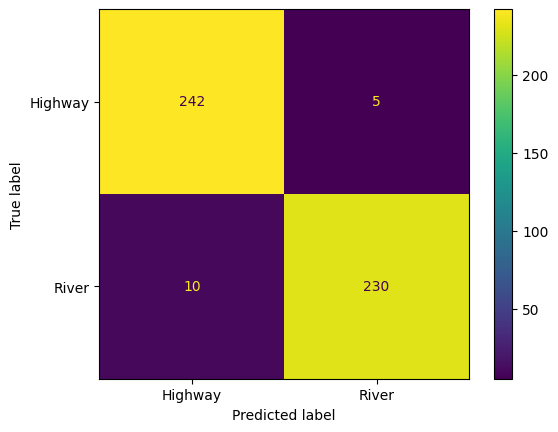

MULTISPECTRAL MODEL


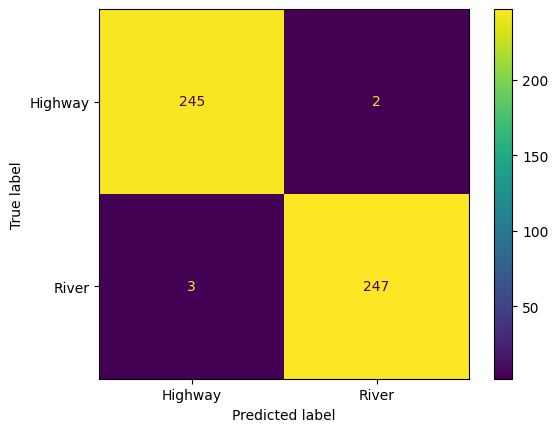

In [55]:
print("RGB MODEL")
road_river_confusion(rgb_model, test_loader, use_rgb_only=True)

print("MULTISPECTRAL MODEL")
road_river_confusion(multi_spectral_model, test_loader)

RGB MODEL


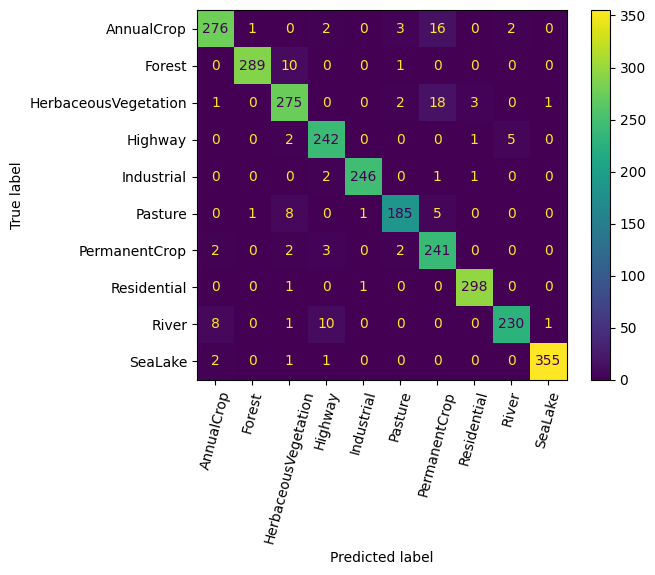

<Figure size 800x800 with 0 Axes>

MULTISPECTRAL MODEL


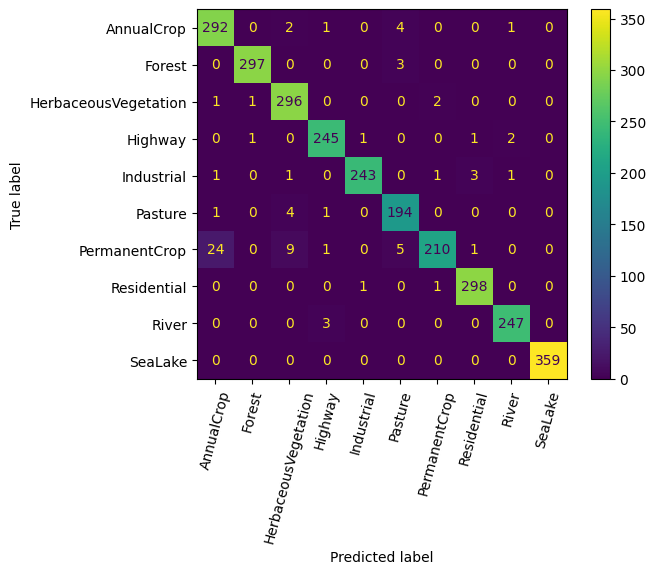

<Figure size 800x800 with 0 Axes>

In [60]:
label_map_inv = {v: k for k, v in label_map.items()}
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch
import numpy as np

def full_confusion_matrix(model, loader, use_rgb_only=False):
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:

            if use_rgb_only:
                x = x[:, :3]

            x = x.to(device)
            preds = model(x).argmax(dim=1).cpu()

            y_true.extend(y.numpy())
            y_pred.extend(preds.numpy())

    # class names in correct order
    class_names = [label_map_inv[i] for i in range(len(label_map_inv))]

    cm = confusion_matrix(y_true, y_pred)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    ).plot(xticks_rotation=75)

    plt.figure(figsize=(8,8))
    plt.show()

print("RGB MODEL")    
full_confusion_matrix(rgb_model, test_loader, use_rgb_only=True)

print("MULTISPECTRAL MODEL")
full_confusion_matrix(multi_spectral_model, test_loader)

In [61]:
# ---------- FULL DATASET EVALUATION ----------

from sklearn.metrics import classification_report, accuracy_score
import torch

# inverse label map → index -> class name
label_map_inv = {v: k for k, v in label_map.items()}


def evaluate_all_classes(model, loader, use_rgb_only=False):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:

            if use_rgb_only:
                x = x[:, :3]

            x = x.to(device)
            preds = model(x).argmax(dim=1).cpu()

            y_true.extend(y.numpy())
            y_pred.extend(preds.numpy())

    # class names in correct order
    class_names = [label_map_inv[i] for i in range(len(label_map_inv))]

    # accuracy
    acc = accuracy_score(y_true, y_pred)

    print(f"Accuracy: {acc:.4f}\n")

    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))


print("=== RGB MODEL ===")
evaluate_all_classes(rgb_model, test_loader, use_rgb_only=True)

print("\n=== MULTISPECTRAL MODEL ===")
evaluate_all_classes(multi_spectral_model, test_loader)

=== RGB MODEL ===
Accuracy: 0.9558

                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.92      0.94       300
              Forest       0.99      0.96      0.98       300
HerbaceousVegetation       0.92      0.92      0.92       300
             Highway       0.93      0.97      0.95       250
          Industrial       0.99      0.98      0.99       250
             Pasture       0.96      0.93      0.94       200
       PermanentCrop       0.86      0.96      0.91       250
         Residential       0.98      0.99      0.99       300
               River       0.97      0.92      0.94       250
             SeaLake       0.99      0.99      0.99       359

            accuracy                           0.96      2759
           macro avg       0.96      0.95      0.95      2759
        weighted avg       0.96      0.96      0.96      2759


=== MULTISPECTRAL MODEL ===
Accuracy: 0.9717

                      precision    recall  f1-